# Q3. Feature Engineering and Regression Pipeline


### 1. Date Feature Engineering


In [2]:
import pandas as pd
df = pd.read_csv('/content/q3_retail_promotions.csv')

display(df.head())
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

display(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(5))

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


,transaction_date,year,month,day_of_week,is_month_end
166,2022-05-15,2022,5,6,0
193,2022-06-05,2022,6,6,0
1025,2024-08-09,2024,8,4,0
818,2024-02-17,2024,2,5,0
332,2022-11-09,2022,11,2,0


### 2. Temporal Train-Test Split


In [3]:
df_sorted = df.sort_values(by='transaction_date').reset_index(drop=True)

split_point = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_point]
test_df = df_sorted.iloc[split_point:]

print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")

display(train_df.head())
display(test_df.head())

Training set size: 960
Testing set size: 240


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
960,2024-06-12,39,medium,semi-urban,category_offer,0,0,8,237,2024,6,2,0
961,2024-06-13,40,medium,semi-urban,free_gift,0,0,8,188,2024,6,3,0
962,2024-06-14,17,large,urban,category_offer,0,1,9,440,2024,6,4,0
963,2024-06-15,37,small,semi-urban,loyalty_points,1,0,6,220,2024,6,5,0
964,2024-06-15,39,medium,rural,free_gift,1,0,6,235,2024,6,5,0


#### Why a random split is inappropriate for time-ordered data

For time-ordered data, a random split is inappropriate because it can lead to **data leakage** and an unrealistic evaluation of the model's performance on future, unseen data.

*   **Data Leakage**: A random split might place future data points into the training set, allowing the model to 'see' information from the future. This can inflate performance metrics during evaluation, as the model has essentially cheated by learning from data that wouldn't be available at prediction time.
*   **Loss of Temporal Order**: Many time series models rely on the sequential nature and temporal dependencies within the data. Randomly shuffling the data destroys this inherent order, making it impossible for the model to learn and exploit time-based patterns (e.g., seasonality, trends, autocorrelation). A model trained on such a shuffled dataset would likely perform poorly on real-world, time-ordered data.
*   **Unrealistic Evaluation**: The goal of predicting time-series data is often to forecast future values based on past observations. A random split evaluates the model's ability to predict a randomly sampled point in time, rather than its ability to predict a future period based on a contiguous past period. A temporal split, where the test set is always chronologically later than the training set, provides a more realistic assessment of the model's predictive power on unseen future data.

### 3. Preprocessing Pipeline


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

TARGET = 'items_sold'

X_train = train_df.drop(columns=[TARGET, 'transaction_date'])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET, 'transaction_date'])
y_test = test_df[TARGET]

categorical_features = ['promotion_type', 'location_type', 'store_size']

numerical_features_to_scale = [
    'is_weekend', 'is_festival', 'competition_density',
    'year', 'month', 'day_of_week', 'is_month_end'
]

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_to_scale),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

preprocessing_pipeline.fit(X_train)

X_train_processed = preprocessing_pipeline.transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

print(f"Shape of processed X_train: {X_train_processed.shape}")
print(f"Shape of processed X_test: {X_test_processed.shape}")

encoded_feature_names = preprocessing_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

all_processed_features = list(numerical_features_to_scale) + list(encoded_feature_names) + ['store_id']

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_processed_features, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_processed_features, index=X_test.index)

display(X_train_processed_df.head())

Shape of processed X_train: (960, 19)
Shape of processed X_test: (240, 19)


,is_weekend,is_festival,competition_density,year,month,day_of_week,is_month_end,promotion_type_bogo,promotion_type_category_offer,promotion_type_flat_discount,promotion_type_free_gift,promotion_type_loyalty_points,location_type_rural,location_type_semi-urban,location_type_urban,store_size_large,store_size_medium,store_size_small,store_id
0,1.590412,-0.361583,0.042569,-1.071337,-1.349015,0.999033,-0.506502,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,28.0
1,1.590412,2.765619,-1.443485,-1.071337,-1.349015,0.999033,-0.506502,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,5.0
2,1.590412,-0.361583,0.414083,-1.071337,-1.349015,1.514110,-0.506502,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,13.0
3,1.590412,-0.361583,0.785596,-1.071337,-1.349015,1.514110,-0.506502,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,17.0
4,-0.628768,-0.361583,-0.700458,-1.071337,-1.349015,-1.576348,-0.506502,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,50.0


### 4. Model Training and Evaluation


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

linear_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_regression_pipeline.fit(X_train, y_train)

y_pred_lr = linear_regression_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:.4f}")
print(f"Linear Regression MAE: {mae_lr:.4f}")


random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

random_forest_pipeline.fit(X_train, y_train)

y_pred_rf = random_forest_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest Regressor RMSE: {rmse_rf:.4f}")
print(f"Random Forest Regressor MAE: {mae_rf:.4f}")

Linear Regression RMSE: 27.1215
Linear Regression MAE: 21.0529
Random Forest Regressor RMSE: 30.5815
Random Forest Regressor MAE: 24.0996


#### Parity Plots (Predicted vs Actual `items_sold`)

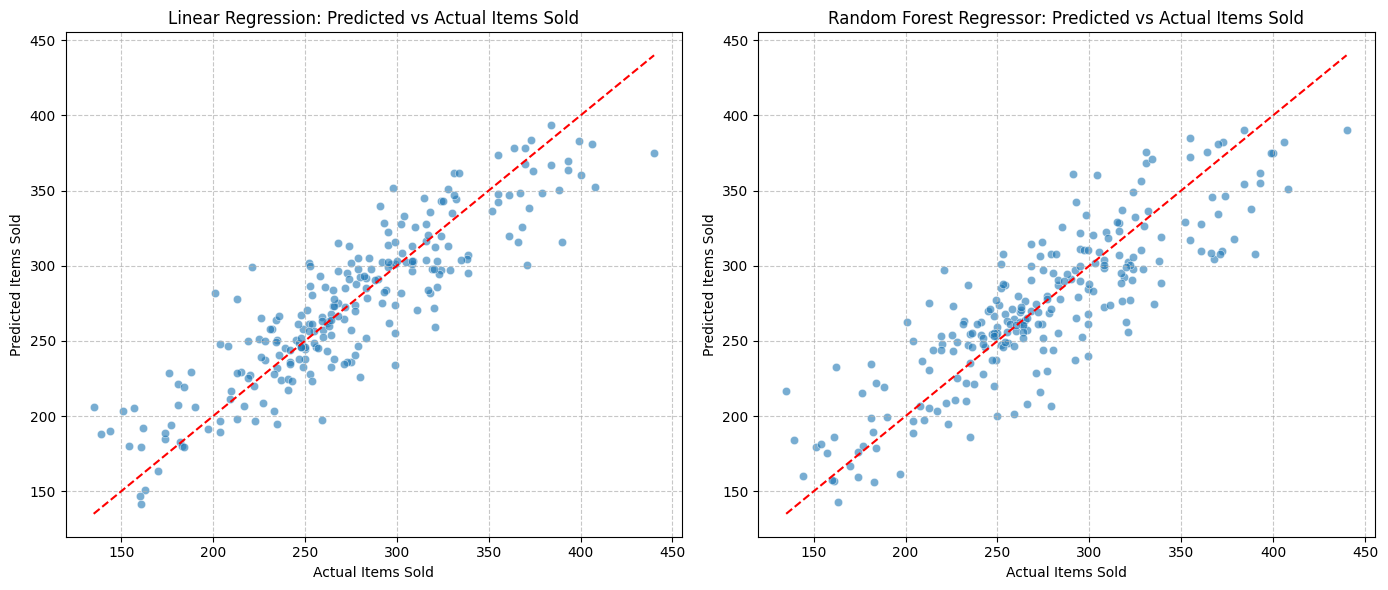

In [10]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression: Predicted vs Actual Items Sold')
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest Regressor: Predicted vs Actual Items Sold')
plt.xlabel('Actual Items Sold')
plt.ylabel('Predicted Items Sold')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Feature Importances from Random Forest Regressor

In [11]:
rf_model = random_forest_pipeline.named_steps['regressor']

feature_importances = rf_model.feature_importances_

feature_names = all_processed_features

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 5 Most Influential Features (Random Forest):")
display(importance_df.head(5))

Top 5 Most Influential Features (Random Forest):


,Feature,Importance
1,is_festival,0.173392
17,store_size_small,0.167074
14,location_type_urban,0.109136
5,day_of_week,0.092194
0,is_weekend,0.055431
